Фильтр Блума

In [31]:
import math
import hashlib
import matplotlib.pyplot as plt

In [32]:
class CountingBloomFilter:
    def __init__(self, n=None, epsilon=None, m=None, k=None):
        if m is None and n is not None and epsilon is not None: 
            self.m = int(- (n * math.log(epsilon)) / (math.log(2) ** 2))
        elif m is not None:
            self.m = m

        if k is None and n is not None:
            self.k = int(round((self.m / n) * math.log(2)))
        elif k is not None:
            self.k = k
        else:
            raise ValueError("Невозможно вычислить k. Надо указать либо n, либо передать k явно.")

        self.counters = [0] * self.m
    
    def hash_pos(self, elem, i):
        variance = f"variant7_bloom_{i}".encode()

        h = hashlib.blake2b(str(elem).encode(), key=variance, digest_size=4)
        hash_val = int.from_bytes(h.digest(), 'big')
        hash_val %= 2 ** 30

        return hash_val % self.m

    def add(self, elem):
        for i in range(self.k):
            pos = self.hash_pos(elem, i)
            self.counters[pos] += 1
    
    def remove(self, elem):
        for i in range(self.k):
            pos = self.hash_pos(elem, i)
            if self.counters[pos] > 0:
                self.counters[pos] -= 1
    
    def check(self, elem):
        return all(self.counters[self.hash_pos(elem, i)] > 0 for i in range(self.k))
    
    def __add__(self, other):
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        new_bf = CountingBloomFilter(m=self.m, k=self.k)
        new_bf.counters = [max(a, b) for a, b in zip(self.counters, other.counters)]
        return new_bf
    
    def __sub__(self, other):
        if self.m != other.m or self.k != other.k:
            raise ValueError("Фильтры должны иметь одинаковые параметры m и k")
        new_bf = CountingBloomFilter(m=self.m, k=self.k)
        new_bf.counters = [min(a, b) for a, b in zip(self.counters, other.counters)]
        return new_bf
    
    def get_theoretical_fpr(self, n_current):
        if self.m == 0 or n_current == 0:
            return 0.0
        return (1 - math.exp(-self.k * n_current / self.m)) ** self.k

ЗАДАНИЕ №1: ФИЛЬТР БЛУМА — ПОЛНЫЙ ПРОГОН ТЕСТОВ

=== Конфигурация 1: n=15000, ε=0.5 ===
Рассчитанные параметры: m=21640, k=1
  Наполненность 25%: Эксперимент=0.1509, Теория=0.1591, Отклонение=0.0082
  Наполненность 50%: Эксперимент=0.2957, Теория=0.2929, Отклонение=0.0028
  Наполненность 75%: Эксперимент=0.4056, Теория=0.4054, Отклонение=0.0002
  Наполненность 95%: Эксперимент=0.4822, Теория=0.4824, Отклонение=0.0002

=== Конфигурация 2: n=100000, ε=0.2 ===
Рассчитанные параметры: m=334983, k=2
  Наполненность 25%: Эксперимент=0.0200, Теория=0.0192, Отклонение=0.0007
  Наполненность 50%: Эксперимент=0.0660, Теория=0.0666, Отклонение=0.0006
  Наполненность 75%: Эксперимент=0.1324, Теория=0.1303, Отклонение=0.0021
  Наполненность 95%: Эксперимент=0.1881, Теория=0.1874, Отклонение=0.0007

=== Конфигурация 3: n=500000, ε=0.05 ===
Рассчитанные параметры: m=3117612, k=4
  Наполненность 25%: Эксперимент=0.0004, Теория=0.0005, Отклонение=0.0001
  Наполненность 50%: Эксперимент=0.0055, Теория=0

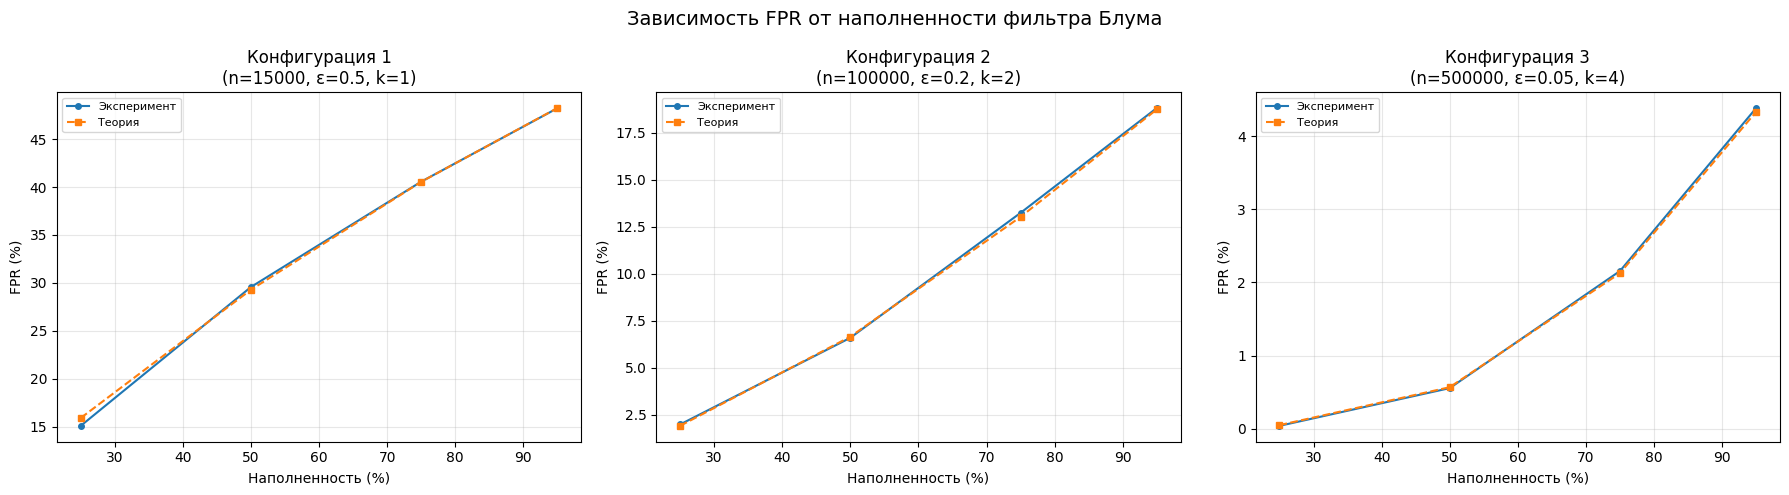


=== Тест объединения (+) ===
Объединение: все проверки пройдены

=== Тест пересечения (-) ===
Пересечение: все проверки пройдены
ВСЕ ТЕСТЫ ЗАВЕРШЕНЫ


In [33]:
def theoretical_fpr(m, k, n_current):
    if m == 0 or n_current == 0:
        return 0.0
    return (1 - math.exp(-k * n_current / m)) ** k



def run_fpr_evaluation():
    configs = [
        {"id": 1, "n": 15_000, "epsilon": 0.5},
        {"id": 2, "n": 100_000, "epsilon": 0.2},
        {"id": 3, "n": 500_000, "epsilon": 0.05},
    ]
    
    fill_levels = [0.25, 0.50, 0.75, 0.95]
    runs = 1
    
    all_results = {}
    
    for cfg in configs:
        n_total = cfg["n"]
        epsilon_target = cfg["epsilon"]
        cfg_id = cfg["id"]
        
        print(f"\n=== Конфигурация {cfg_id}: n={n_total}, ε={epsilon_target} ===")
        
        bf_template = CountingBloomFilter(n=n_total, epsilon=epsilon_target)
        m, k = bf_template.m, bf_template.k
        print(f"Рассчитанные параметры: m={m}, k={k}")
        
        results = []
        
        for level in fill_levels:
            n_current = int(n_total * level)
            fp_rates = []
            
            for run in range(runs):
                bf = CountingBloomFilter(n=n_total, epsilon=epsilon_target)
                
                added = [f"cfg{cfg_id}_run{run}_item{i}" for i in range(n_current)]
                for elem in added:
                    bf.add(elem)
                
                test_elements = [f"cfg{cfg_id}_run{run}_guest{i}" for i in range(n_current)]
                false_positives = sum(1 for elem in test_elements if bf.check(elem))
                fp_rate = false_positives / len(test_elements)
                fp_rates.append(fp_rate)
            
            avg_fp = sum(fp_rates) / len(fp_rates)
            theor_fp = theoretical_fpr(m, k, n_current)
            
            results.append({
                "level": level,
                "n_current": n_current,
                "avg_fp": avg_fp,
                "theoretical_fp": theor_fp,
                "deviation": abs(avg_fp - theor_fp)
            })
            
            print(f"  Наполненность {level*100:2.0f}%: "
                  f"Эксперимент={avg_fp:.4f}, Теория={theor_fp:.4f}, "
                  f"Отклонение={abs(avg_fp - theor_fp):.4f}")
        
        all_results[cfg_id] = {
            "n": n_total,
            "epsilon": epsilon_target,
            "m": m,
            "k": k,
            "results": results
        }
    
    return all_results

def plot_fpr_dependency(results_dict):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle('Зависимость FPR от наполненности фильтра Блума', fontsize=14)
    
    for idx, (cfg_id, data) in enumerate(results_dict.items()):
        ax = axes[idx]
        levels = [r["level"] * 100 for r in data["results"]]
        exp_fps = [r["avg_fp"] * 100 for r in data["results"]]
        theor_fps = [r["theoretical_fp"] * 100 for r in data["results"]]
        
        ax.plot(levels, exp_fps, 'o-', label='Эксперимент', markersize=4)
        ax.plot(levels, theor_fps, 's--', label='Теория', markersize=4)
        ax.set_xlabel('Наполненность (%)')
        ax.set_ylabel('FPR (%)')
        ax.set_title(f'Конфигурация {cfg_id}\n(n={data["n"]}, ε={data["epsilon"]}, k={data["k"]})')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def test_union_operation():
    """
    Требование 1.6: Тест объединения фильтров (оператор +).
    Объединение: счётчики = max(a, b)
    """
    print("\n=== Тест объединения (+) ===")
    
    bf1 = CountingBloomFilter(n=1000, epsilon=0.1)
    bf2 = CountingBloomFilter(n=1000, epsilon=0.1)
    
    bf1.add("common")
    bf1.add("only_in_1")
    bf2.add("common")
    bf2.add("only_in_2")
    
    bf_union = bf1 + bf2
    
    assert bf_union.check("common") == True, "Общий элемент не найден в объединении"
    assert bf_union.check("only_in_1") == True, "Элемент из bf1 не найден в объединении"
    assert bf_union.check("only_in_2") == True, "Элемент из bf2 не найден в объединении"
    assert bf_union.check("not_present") == False, "Отсутствующий элемент ложно найден"
    
    print("Объединение: все проверки пройдены")
    return True


def test_intersection_operation():
    print("\n=== Тест пересечения (-) ===")
    
    bf1 = CountingBloomFilter(n=1000, epsilon=0.1)
    bf2 = CountingBloomFilter(n=1000, epsilon=0.1)
    
    bf1.add("common")
    bf1.add("only_in_1")
    bf1.add("common")
    bf2.add("common")
    bf2.add("only_in_2")
    
    bf_inter = bf1 - bf2
    
    assert bf_inter.check("common") == True, "Общий элемент не найден в пересечении"
    assert bf_inter.check("only_in_1") == False, "Уникальный элемент bf1 ложно найден"
    assert bf_inter.check("only_in_2") == False, "Уникальный элемент bf2 ложно найден"
    assert bf_inter.check("not_present") == False, "Отсутствующий элемент ложно найден"
    
    print("Пересечение: все проверки пройдены")
    return True

def run_all_bloom_tests():
    print("ЗАДАНИЕ №1: ФИЛЬТР БЛУМА — ПОЛНЫЙ ПРОГОН ТЕСТОВ")
    
    results = run_fpr_evaluation()
    
    plot_fpr_dependency(results)
    
    test_union_operation()
    test_intersection_operation()
    
    print("ВСЕ ТЕСТЫ ЗАВЕРШЕНЫ")
    
    return results


if __name__ == "__main__":
    run_all_bloom_tests()